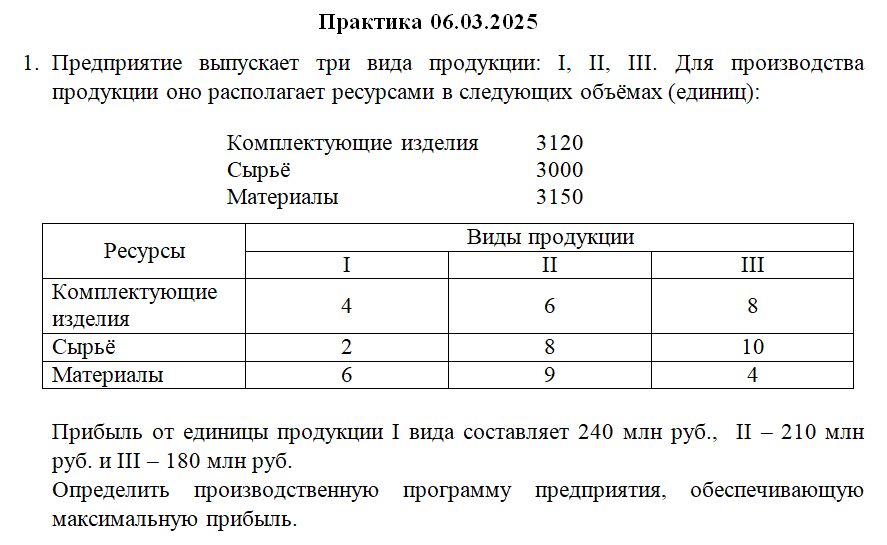

In [1]:
import numpy as np
from scipy.optimize import linprog

c = np.array([240.0, 210.0, 180.0])

A = np.array([
    [4, 6, 8],   # комплектующие изделия, ед.
    [2, 8, 10],  # сырьё, ед.
    [6, 9, 4],   # материалы, ед.
], dtype=float)

b = np.array([3120.0, 3000.0, 3150.0], dtype=float)
bounds = [(0, None)] * 3
res = linprog(-c, A_ub=A, b_ub=b, bounds=bounds, method="highs")

if not res.success:
    raise RuntimeError(f"LP not solved: {res.message}")

x = res.x
profit = c @ x  # значение исходной max-цели

print("Оптимальный план:")
print(f"x1 (прод. I)   = {x[0]:.6g}")
print(f"x2 (прод. II)  = {x[1]:.6g}")
print(f"x3 (прод. III) = {x[2]:.6g}")
print(f"Максимальная прибыль = {profit:.6g}")

slack = b - A @ x
active = [i for i, s in enumerate(slack) if abs(s) < 1e-8]
print("Номера активных ограничений (0-комплект.; 1-сырьё; 2-материалы):", active)

ineqlin = getattr(res, "ineqlin", None)
if ineqlin is not None and hasattr(ineqlin, "marginals"):
    print("Двойственные оценки (цены ресурсов):", ineqlin.marginals)


Оптимальный план:
x1 (прод. I)   = 397.5
x2 (прод. II)  = 0
x3 (прод. III) = 191.25
Максимальная прибыль = 129825
Номера активных ограничений (0-комплект.; 1-сырьё; 2-материалы): [0, 2]
Двойственные оценки (цены ресурсов): [ -3.75  -0.   -37.5 ]


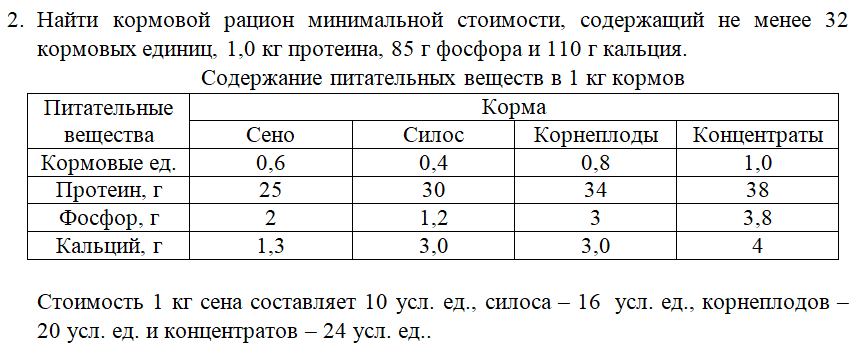

In [2]:
c = np.array([10.0, 16.0, 20.0, 24.0])
nutr = np.array([
    [0.6, 0.4, 0.8, 1.0],  # кормовые ед.
    [25,  30,  34,  38],   # протеин, г
    [2.0, 1.2, 3.0, 3.8],  # фосфор, г
    [1.3, 3.0, 3.0, 4.0],  # кальций, г
], dtype=float)

req = np.array([32.0, 1000.0, 85.0, 110.0])  # требования ≥
A_ub = -nutr
b_ub = -req
bounds = [(0, None)] * 4
res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
if not res.success:
    raise RuntimeError(f"LP not solved: {res.message}")

x = res.x
cost = float(c @ x)

print("Оптимальный рацион (кг):")
print(f"Сено        = {x[0]:.6g}")
print(f"Силос       = {x[1]:.6g}")
print(f"Корнеплоды  = {x[2]:.6g}")
print(f"Концентраты = {x[3]:.6g}")
print(f"Минимальная стоимость = {cost:.6g} у.е.")

provided = nutr @ x
names = ["Корм. ед.", "Протеин, г", "Фосфор, г", "Кальций, г"]
for nm, got, need in zip(names, provided, req):
    print(f"{nm}: {got:.6g} (треб. ≥ {need})")

slack = req - provided
active = [i for i, s in enumerate(slack) if abs(s) < 1e-8]
print("Активные ограничения (индексы 0..3):", active)

ineqlin = getattr(res, "ineqlin", None)
if ineqlin is not None and hasattr(ineqlin, "marginals"):
    print("Цены ресурсов (двойственные, по порядку требований):", ineqlin.marginals)


Оптимальный рацион (кг):
Сено        = 16.3636
Силос       = 0
Корнеплоды  = 0
Концентраты = 22.1818
Минимальная стоимость = 696 у.е.
Корм. ед.: 32 (треб. ≥ 32.0)
Протеин, г: 1252 (треб. ≥ 1000.0)
Фосфор, г: 117.018 (треб. ≥ 85.0)
Кальций, г: 110 (треб. ≥ 110.0)
Активные ограничения (индексы 0..3): [0, 3]
Цены ресурсов (двойственные, по порядку требований): [-8. -0. -0. -4.]


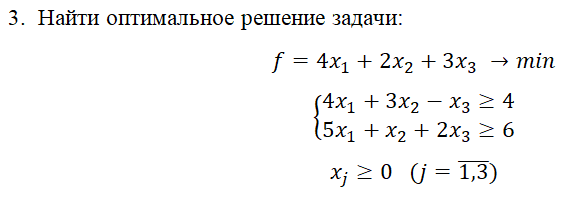

In [3]:
c = np.array([4.0, 2.0, 3.0])  # коэффициенты цели для минимизации

A_ge = np.array([
    [4.0, 3.0, -1.0],
    [5.0, 1.0,  2.0],
], dtype=float)
b_ge = np.array([4.0, 6.0])

A_ub = -A_ge
b_ub = -b_ge

bounds = [(0, None)] * 3

res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
if not res.success:
    raise RuntimeError(f"LP not solved: {res.message}")

x = res.x
obj = float(c @ x)

print("Оптимальное решение:")
print(f"x1 = {x[0]:.6g}, x2 = {x[1]:.6g}, x3 = {x[2]:.6g}")
print(f"Минимум целевой функции = {obj:.6g}")

lhs = A_ge @ x
names = ["4x1 + 3x2 - x3 ≥ 4", "5x1 + x2 + 2x3 ≥ 6"]
for nm, val, rhs in zip(names, lhs, b_ge):
    print(f"{nm}: {val:.6g}  (порог {rhs})")

slack_ge = lhs - b_ge
active = [i for i, s in enumerate(slack_ge) if abs(s) < 1e-8]
print("Активные ограничения (индексы):", active)

ineqlin = getattr(res, "ineqlin", None)
if ineqlin is not None and hasattr(ineqlin, "marginals"):
    y_le = np.asarray(ineqlin.marginals)
    y_ge = -y_le
    print("Двойственные переменные для исходных ≥:", y_ge)


Оптимальное решение:
x1 = 1.2, x2 = 0, x3 = 0
Минимум целевой функции = 4.8
4x1 + 3x2 - x3 ≥ 4: 4.8  (порог 4.0)
5x1 + x2 + 2x3 ≥ 6: 6  (порог 6.0)
Активные ограничения (индексы): [1]
Двойственные переменные для исходных ≥: [0.  0.8]
